# Shows a basic pandas CSV import with explicit zipfile handling
by "explicit" we mean that the file action code is visible in this script

In [1]:
import pandas as pd
import zipfile as z
import pathlib
import os
import shutil

current_working_dir = os.getcwd()

print("current_working_dir = " + current_working_dir)
print("OS name = " + os.name)



current_working_dir = c:\Users\stevewatkins\Downloads\repos\PythonForDataAnalysis\IpythonNotebooks
OS name = nt


In [2]:
p = pathlib.Path("../data")

pathfile_to_unzip = "../data/trips.csv.zip"

if os.name != "posix":
    pathfile_to_unzip = "../data\\trips.csv.zip"

#get a list of dirs before unzip
dirs_before_unz = [x for x in p.iterdir() if x.is_dir()]

zf = z.ZipFile(pathfile_to_unzip,"r")
zf.extractall("../data")
zf.close()

## Context Manager version of above 
#with z.ZipFile("Data/trips.csv.zip","r") as zf:
#    zf.extractall("Data")

In [3]:
# WINDOWS or MAC - relative path - read CSV into dataframe
# df1 = pd.read_csv("../data/demo_AmexTransactions.csv", header=None)
df3 = pd.read_csv("../data/trips.csv", header="infer")

In [4]:
## view results

#df1.head(10)
#df1.tail(2)
df3.sample(5)
#df4[["my_datetime", "source"]]

##series
#df4['user_id']

#df4[df4.source == 'Reddit']
#df4.sample(100)

#df4[['source']].count()
#df4[['source']].sum()
#df4[['user_id']].sum()

#df1
#df3


,Unnamed: 0,id,duration,start_date,start_station,end_date,end_station,bike_number,sub_type,zip_code,birth_date,gender
742926,742926,750012,600,2013-05-04 15:20:00,49.0,2013-05-04 15:30:00,99.0,B00392,Casual,NaN,NaN,NaN
1143744,1143744,1151941,300,2013-08-16 13:15:00,76.0,2013-08-16 13:20:00,74.0,B00281,Registered,'01902,NaN,Female
734361,734361,741412,360,2013-05-01 21:16:00,73.0,2013-05-01 21:22:00,79.0,B00448,Registered,'02143,NaN,Male
1119578,1119578,1127734,840,2013-08-11 18:12:00,58.0,2013-08-11 18:26:00,103.0,T01011,Casual,NaN,NaN,NaN
1434512,1434512,1443254,3960,2013-10-17 16:11:00,58.0,2013-10-17 17:17:00,116.0,T01093,Casual,NaN,NaN,NaN


In [5]:
# group by bike_number and zip_code: counts and total duration in minutes
df3_grouped = (
    df3.groupby(['bike_number', 'zip_code'])
    .agg(
        trip_count=('duration', 'count'),
        total_duration_minutes=('duration', lambda x: x.sum() / 60)
    )
    .reset_index()
    .sort_values('trip_count', ascending=False)
)

df3_grouped

,bike_number,zip_code,trip_count,total_duration_minutes
33910,B00233,'02118,199,1952.583333
62795,B00433,'02118,198,1879.266667
75011,B00519,'02118,198,1971.366667
62932,B00434,'02118,195,2297.700000
81288,B00563,'02118,193,2109.566667
...,...,...,...,...
147525,b00225,'02703,1,17.450000
147524,b00225,'02635,1,3.000000
147523,b00225,'02537,1,10.650000
147522,b00225,'02493,1,9.933333


## Relational decomposition demo (SQLite)
We'll treat `bike_number` as a text identifier, then decompose `df3` into:
- `bikes` (dimension)
- `riders` (dimension)
- `trips` (fact table)

In [6]:
import sqlite3

# make a teaching-friendly copy
df_rel = df3.copy()

# treat identifiers/categorical keys as text
for c in ["bike_number", "zip_code", "sub_type", "birth_date", "gender"]:
    df_rel[c] = df_rel[c].astype("string").fillna("")

print(df_rel[["bike_number", "zip_code"]].dtypes)
df_rel[["bike_number", "zip_code"]].head()

bike_number    string[python]
zip_code       string[python]
dtype: object


,bike_number,zip_code
0,B00468,'97217
1,B00554,'02215
2,B00456,'02108
3,B00554,'02116
4,B00554,'97214


In [7]:
# build a small relational model in SQLite memory DB
db_rel = sqlite3.connect(":memory:")
cur = db_rel.cursor()

cur.executescript("""
DROP TABLE IF EXISTS trips;
DROP TABLE IF EXISTS riders;
DROP TABLE IF EXISTS bikes;

CREATE TABLE bikes (
    bike_number TEXT PRIMARY KEY
);

CREATE TABLE riders (
    rider_id INTEGER PRIMARY KEY AUTOINCREMENT,
    sub_type TEXT,
    zip_code TEXT,
    birth_date TEXT,
    gender TEXT,
    UNIQUE(sub_type, zip_code, birth_date, gender)
);

CREATE TABLE trips (
    trip_id INTEGER PRIMARY KEY,
    duration_seconds INTEGER NOT NULL,
    start_date TEXT,
    end_date TEXT,
    start_station INTEGER,
    end_station INTEGER,
    bike_number TEXT NOT NULL,
    rider_id INTEGER NOT NULL,
    FOREIGN KEY (bike_number) REFERENCES bikes(bike_number),
    FOREIGN KEY (rider_id) REFERENCES riders(rider_id)
);
""")

# bikes dimension
bikes_dim = df_rel[["bike_number"]].drop_duplicates()
bikes_dim.to_sql("bikes", db_rel, if_exists="append", index=False)

# riders dimension
rider_cols = ["sub_type", "zip_code", "birth_date", "gender"]
riders_dim = df_rel[rider_cols].drop_duplicates()
riders_dim.to_sql("riders", db_rel, if_exists="append", index=False)

# map rider attributes to surrogate key
rider_lookup = pd.read_sql_query(
    "SELECT rider_id, sub_type, zip_code, birth_date, gender FROM riders",
    db_rel
)

trips_enriched = df_rel.merge(rider_lookup, on=rider_cols, how="left")

trips_fact = trips_enriched.rename(columns={
    "id": "trip_id",
    "duration": "duration_seconds"
})[
    ["trip_id", "duration_seconds", "start_date", "end_date",
     "start_station", "end_station", "bike_number", "rider_id"]
].copy()

# ensure numeric where expected
trips_fact["trip_id"] = pd.to_numeric(trips_fact["trip_id"], errors="coerce")
trips_fact["duration_seconds"] = pd.to_numeric(trips_fact["duration_seconds"], errors="coerce")
trips_fact = trips_fact.dropna(subset=["trip_id", "duration_seconds", "rider_id"])
trips_fact["trip_id"] = trips_fact["trip_id"].astype(int)
trips_fact["duration_seconds"] = trips_fact["duration_seconds"].astype(int)
trips_fact["rider_id"] = trips_fact["rider_id"].astype(int)

trips_fact.to_sql("trips", db_rel, if_exists="append", index=False)

print("rows loaded:",
      "bikes =", pd.read_sql_query("SELECT COUNT(*) AS n FROM bikes", db_rel).iloc[0,0],
      "| riders =", pd.read_sql_query("SELECT COUNT(*) AS n FROM riders", db_rel).iloc[0,0],
      "| trips =", pd.read_sql_query("SELECT COUNT(*) AS n FROM trips", db_rel).iloc[0,0])

rows loaded: bikes = 1164 | riders = 4225 | trips = 1570001


In [8]:
# same aggregation question, now from relational tables
query = """
SELECT
    t.bike_number,
    r.zip_code,
    COUNT(*) AS trip_count,
    ROUND(SUM(t.duration_seconds) / 60.0, 2) AS total_duration_minutes
FROM trips t
JOIN riders r
  ON r.rider_id = t.rider_id
GROUP BY t.bike_number, r.zip_code
ORDER BY trip_count DESC, total_duration_minutes DESC
LIMIT 20;
"""
pd.read_sql_query(query, db_rel)

,bike_number,zip_code,trip_count,total_duration_minutes
0,B00548,,723,18539.07
1,B00439,,680,17012.80
2,B00454,,677,17987.10
3,B00490,,667,17827.00
4,B00391,,664,16205.15
5,B00537,,661,17009.32
6,B00444,,660,17466.58
7,B00329,,660,17403.67
8,B00424,,653,17644.85
9,B00363,,651,16472.95


## ERD + decomposition flow (Mermaid)

```mermaid
erDiagram
    BIKES {
        TEXT bike_number PK
    }

    RIDERS {
        INTEGER rider_id PK
        TEXT sub_type
        TEXT zip_code
        TEXT birth_date
        TEXT gender
    }

    TRIPS {
        INTEGER trip_id PK
        INTEGER duration_seconds
        TEXT start_date
        TEXT end_date
        INTEGER start_station
        INTEGER end_station
        TEXT bike_number FK
        INTEGER rider_id FK
    }

    BIKES ||--o{ TRIPS : bike_number
    RIDERS ||--o{ TRIPS : rider_id
```

```mermaid
flowchart LR
    A[df3 flat table<br/>one row per trip] --> B[Create bikes dimension<br/>distinct bike_number]
    A --> C[Create riders dimension<br/>distinct sub_type, zip_code, birth_date, gender]
    C --> D[Assign rider_id surrogate key]
    A --> E[Build trips fact<br/>trip_id, duration_seconds, stations, bike_number]
    D --> E
    B --> F[(bikes)]
    C --> G[(riders)]
    E --> H[(trips)]
    F --> H
    G --> H
```

In [9]:
from IPython.display import HTML, display

erd = r'''
erDiagram
    BIKES {
        TEXT bike_number PK
    }

    RIDERS {
        INTEGER rider_id PK
        TEXT sub_type
        TEXT zip_code
        TEXT birth_date
        TEXT gender
    }

    TRIPS {
        INTEGER trip_id PK
        INTEGER duration_seconds
        TEXT start_date
        TEXT end_date
        INTEGER start_station
        INTEGER end_station
        TEXT bike_number FK
        INTEGER rider_id FK
    }

    BIKES ||--o{ TRIPS : bike_number
    RIDERS ||--o{ TRIPS : rider_id
'''

flow = r'''
flowchart LR
    A[df3 flat table<br/>one row per trip] --> B[Create bikes dimension<br/>distinct bike_number]
    A --> C[Create riders dimension<br/>distinct sub_type, zip_code, birth_date, gender]
    C --> D[Assign rider_id surrogate key]
    A --> E[Build trips fact<br/>trip_id, duration_seconds, stations, bike_number]
    D --> E
    B --> F[(bikes)]
    C --> G[(riders)]
    E --> H[(trips)]
    F --> H
    G --> H
'''

html = f'''
<div style="font-family:Segoe UI,Arial,sans-serif;margin:8px 0 6px 0;"><h3 style="margin:0;">ERD + Decomposition Flow</h3></div>
<div class="mermaid">{erd}</div>
<hr/>
<div class="mermaid">{flow}</div>
<script type="module">
import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
mermaid.initialize({{ startOnLoad: false, securityLevel: 'loose', theme: 'default' }});
await mermaid.run({{ querySelector: '.mermaid' }});
</script>
'''

display(HTML(html))

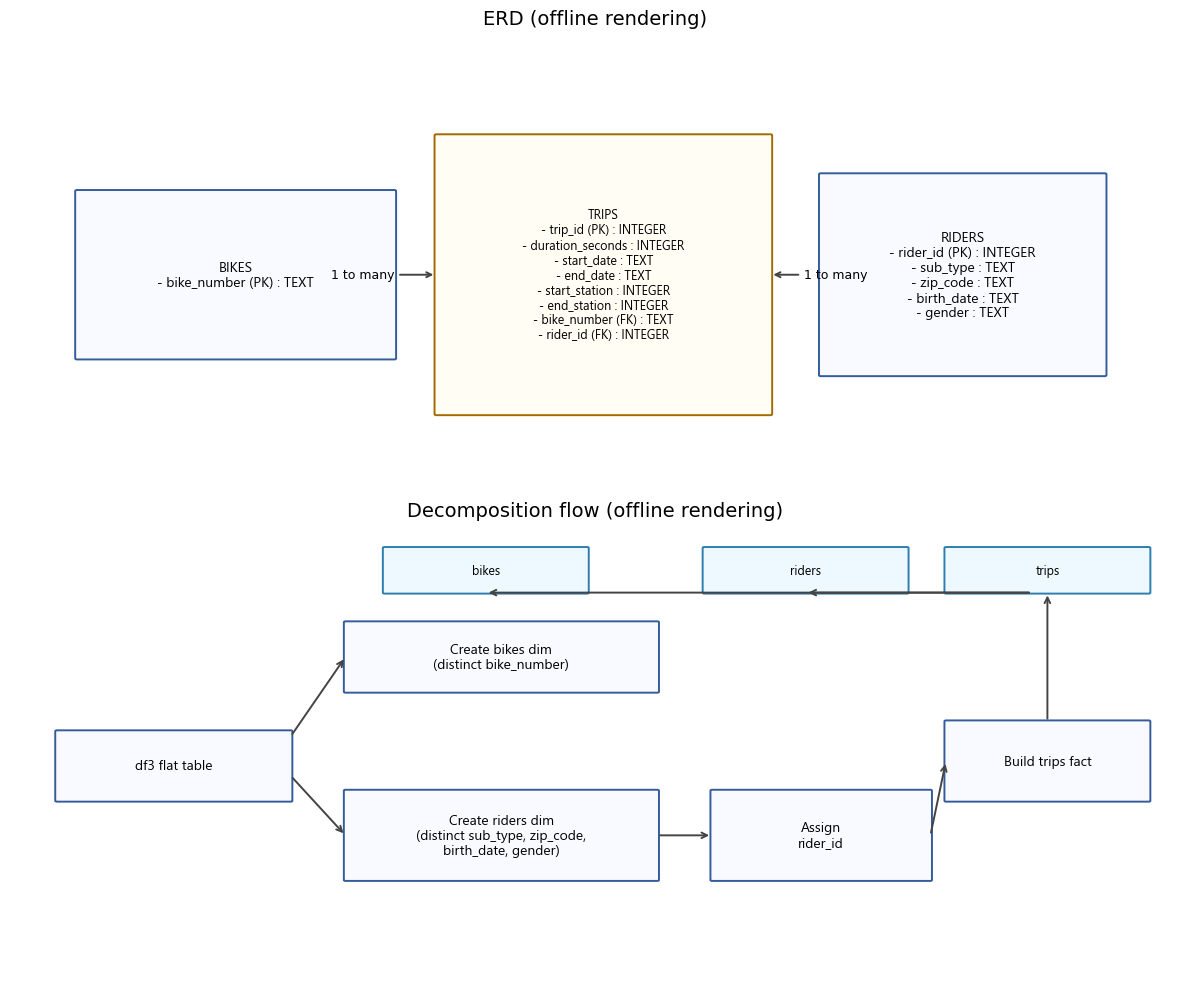

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def add_box(ax, x, y, w, h, text, fc="#F8FAFF", ec="#355C9A", fontsize=10):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", linewidth=1.4, edgecolor=ec, facecolor=fc)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize, family="Segoe UI")
    return (x + w/2, y + h/2)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- ERD ---
ax = axes[0]
ax.set_title("ERD (offline rendering)", fontsize=14, pad=12)
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")

add_box(ax, 0.8, 2.3, 3.8, 3.0,
        "BIKES\n- bike_number (PK) : TEXT")
add_box(ax, 5.1, 1.3, 4.0, 5.0,
        "TRIPS\n- trip_id (PK) : INTEGER\n- duration_seconds : INTEGER\n- start_date : TEXT\n- end_date : TEXT\n- start_station : INTEGER\n- end_station : INTEGER\n- bike_number (FK) : TEXT\n- rider_id (FK) : INTEGER",
        fc="#FFFDF4", ec="#A36A00", fontsize=9)
add_box(ax, 9.7, 2.0, 3.4, 3.6,
        "RIDERS\n- rider_id (PK) : INTEGER\n- sub_type : TEXT\n- zip_code : TEXT\n- birth_date : TEXT\n- gender : TEXT")

ax.annotate("1 to many", xy=(5.1, 3.8), xytext=(4.6, 3.8),
            arrowprops=dict(arrowstyle="->", lw=1.4, color="#444"), va="center", ha="right", fontsize=9)
ax.annotate("1 to many", xy=(9.1, 3.8), xytext=(9.5, 3.8),
            arrowprops=dict(arrowstyle="->", lw=1.4, color="#444"), va="center", ha="left", fontsize=9)

# --- Flow chart ---
ax = axes[1]
ax.set_title("Decomposition flow (offline rendering)", fontsize=14, pad=12)
ax.set_xlim(0, 15)
ax.set_ylim(0, 9)
ax.axis("off")

add_box(ax, 0.6, 3.6, 3.0, 1.4, "df3 flat table")
add_box(ax, 4.3, 5.8, 4.0, 1.4, "Create bikes dim\n(distinct bike_number)")
add_box(ax, 4.3, 2.0, 4.0, 1.8, "Create riders dim\n(distinct sub_type, zip_code,\nbirth_date, gender)")
add_box(ax, 9.0, 2.0, 2.8, 1.8, "Assign\nrider_id")
add_box(ax, 12.0, 3.6, 2.6, 1.6, "Build trips fact")

add_box(ax, 4.8, 7.8, 2.6, 0.9, "bikes", fc="#EEF9FF", ec="#2E7DAF", fontsize=9)
add_box(ax, 8.9, 7.8, 2.6, 0.9, "riders", fc="#EEF9FF", ec="#2E7DAF", fontsize=9)
add_box(ax, 12.0, 7.8, 2.6, 0.9, "trips", fc="#EEF9FF", ec="#2E7DAF", fontsize=9)

arrow = dict(arrowstyle="->", lw=1.4, color="#444")
ax.annotate("", xy=(4.3, 6.5), xytext=(3.6, 4.9), arrowprops=arrow)
ax.annotate("", xy=(4.3, 2.9), xytext=(3.6, 4.1), arrowprops=arrow)
ax.annotate("", xy=(9.0, 2.9), xytext=(8.3, 2.9), arrowprops=arrow)
ax.annotate("", xy=(12.0, 4.4), xytext=(11.8, 2.9), arrowprops=arrow)
ax.annotate("", xy=(13.3, 7.8), xytext=(13.3, 5.2), arrowprops=arrow)
ax.annotate("", xy=(6.1, 7.8), xytext=(13.1, 7.8), arrowprops=arrow)
ax.annotate("", xy=(10.2, 7.8), xytext=(13.1, 7.8), arrowprops=arrow)

plt.tight_layout()
plt.show()